[2026-04-03 Fiddler](https://thefiddler.substack.com/p/can-you-rile-and-grace-the-polyhedron)
====================

Fiddler
-------
I worked this out mentally while taking a walk, excluding the numerical approximation.

Put one edge flush to the tunnel.  The problem becomes finding the circle circumscribing
the isosceles triangle with edges with lengths $1, \sqrt3/2, \sqrt3/2$.

Put two of the vertices of the triangle on the x-axis at 1/2 and -1/2.  Put the last
vertex on the y-axis at $y$ where $y^2 + 1/4 = 3/4$, so $y = 1/\sqrt2$.

The center of the circumscribing circle is on the y-axis at $y = 1/\sqrt2 - r$, where $r$
is the radius.  Then, $r^2 = (1/\sqrt2-r)^2 + 1/4 = 1/2 - 2r/\sqrt2 + r^2 + 1/4$, so
$r = 3/4\sqrt2 \approx 0.53$.

Extra credit
------------
My approach will be to have two opposing faces flush with the tunnel, then rotate
around the axis connecting their centers to minimize the area of the 2-dimensional
projection.

First take the Cartesian coordinates of the vertices of the dodecahedron centered
at $(0,0,0)$ and rotate them around the x-axis until ten of the vertices are at
$z = \pm\sqrt{\frac{\sqrt5\phi^2}{20}}$.  Then rotate them around the z-axis to
minimize the area of the polygon defined by projecting all the edges onto the x-z
plane.

In [1]:
v = ([(golden_ratio/2*x,golden_ratio/2*y,golden_ratio/2*z) for x in [1,-1] for y in [1,-1] for z in [1,-1]] 
     + [(0, golden_ratio^2/2*y, 1/2*z) for y in [1,-1] for z in [1,-1]]
     + [(golden_ratio^2/2*x, 1/2*y, 0) for x in [1,-1] for y in [1,-1]]
     + [(1/2*x, 0, golden_ratio^2/2*z) for x in [1,-1] for z in [1,-1]])
v

[(1/2*golden_ratio, 1/2*golden_ratio, 1/2*golden_ratio),
 (1/2*golden_ratio, 1/2*golden_ratio, -1/2*golden_ratio),
 (1/2*golden_ratio, -1/2*golden_ratio, 1/2*golden_ratio),
 (1/2*golden_ratio, -1/2*golden_ratio, -1/2*golden_ratio),
 (-1/2*golden_ratio, 1/2*golden_ratio, 1/2*golden_ratio),
 (-1/2*golden_ratio, 1/2*golden_ratio, -1/2*golden_ratio),
 (-1/2*golden_ratio, -1/2*golden_ratio, 1/2*golden_ratio),
 (-1/2*golden_ratio, -1/2*golden_ratio, -1/2*golden_ratio),
 (0, 1/2*golden_ratio^2, 1/2),
 (0, 1/2*golden_ratio^2, -1/2),
 (0, -1/2*golden_ratio^2, 1/2),
 (0, -1/2*golden_ratio^2, -1/2),
 (1/2*golden_ratio^2, 1/2, 0),
 (1/2*golden_ratio^2, -1/2, 0),
 (-1/2*golden_ratio^2, 1/2, 0),
 (-1/2*golden_ratio^2, -1/2, 0),
 (1/2, 0, 1/2*golden_ratio^2),
 (1/2, 0, -1/2*golden_ratio^2),
 (-1/2, 0, 1/2*golden_ratio^2),
 (-1/2, 0, -1/2*golden_ratio^2)]

In [2]:
theta = var("theta")
v1 = [(x,y*cos(theta)+z*sin(theta),z*cos(theta)-y*sin(theta)) for (x,y,z) in v]
solve(v1[2][2] == v1[16][2], theta)

[sin(theta) == 1/2*(sqrt(5) - 1)*cos(theta)]

In [3]:
v2 = [(x.substitute(theta == arctan((sqrt(5)-1)/2)),
       y.substitute(theta == arctan((sqrt(5)-1)/2)),
       z.substitute(theta == arctan((sqrt(5)-1)/2))) for (x,y,z) in v1]

In [4]:
v3 = [(x*cos(theta)+y*sin(theta),z) for (x,y,z) in v2]

In [5]:
(line([v2[2],v2[16],v2[18],v2[6],v2[10],v2[2]])
 + line([v2[2],v2[13],v2[3],v2[11],v2[10]])
 + line([v2[11],v2[7],v2[15],v2[6]])
 + line([v2[16],v2[0],v2[12],v2[13]])
 + line([v2[0],v2[8],v2[4],v2[18]])
 + line([v2[8],v2[9],v2[5],v2[14],v2[4]])
 + line([v2[14],v2[15]])
 + line([v2[12],v2[1],v2[17],v2[3]])
 + line([v2[1],v2[9]])
 + line([v2[5],v2[19],v2[7]])
 + line([v2[17],v2[19]])
)

Graphics3d Object

In [6]:
def proj(t, c, hilite=[]):
    v4 = [(x.substitute(theta == t), z) for (x,z) in v3]
    return (line([v4[2],v4[16],v4[18],v4[6],v4[10],v4[2]], color=c)
            + line([v4[2],v4[13],v4[3],v4[11],v4[10]], color=c)
            + line([v4[11],v4[7],v4[15],v4[6]], color=c)
            + line([v4[16],v4[0],v4[12],v4[13]], color=c)
            + line([v4[0],v4[8],v4[4],v4[18]], color=c)
            + line([v4[8],v4[9],v4[5],v4[14],v4[4]], color=c)
            + line([v4[14],v4[15]], color=c)
            + line([v4[12],v4[1],v4[17],v4[3]], color=c)
            + line([v4[1],v4[9]], color=c)
            + line([v4[5],v4[19],v4[7]], color=c)
            + line([v4[17],v4[19]], color=c)
            + line([v4[i] for i in hilite], color="red")
           )

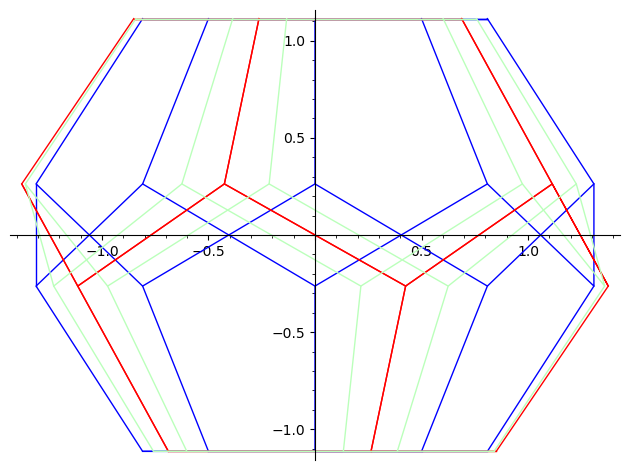

In [7]:
proj(0,"blue") + proj(pi/10, "red") + proj(pi/20, "#bfb")

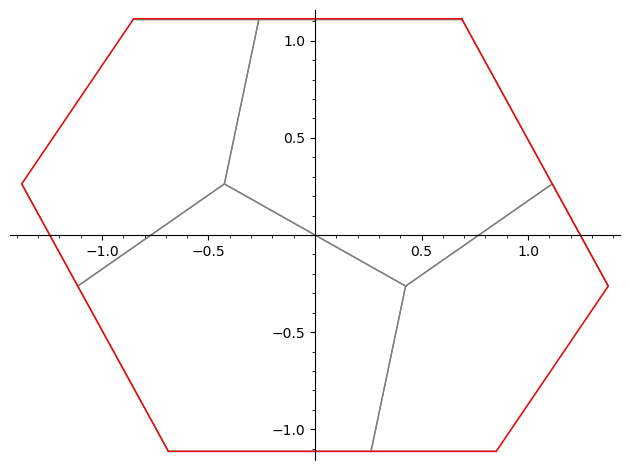

In [8]:
proj(pi/10, "gray", hilite=[2, 13, 12, 1, 9, 5, 14, 15, 6, 10, 2])

So it turns out that two adjacent faces and their opposite faces are flush with the tunnel
(the top, bottom, upper-right, and lower-left segments in the figure above), as well as a
pair of opposite edges (the upper-left and lower-right segments in the figure above), while
four faces face one end of the tunnel and their opposites face the other end of the tunnel.

In [9]:
def polygon_area(vertices):
    # Shoelace formula: 0.5 * abs(x1y2 + x2y3... - (y1x2 + y2x3...))
    x = [v[0] for v in vertices]
    y = [v[1] for v in vertices]
    return 1/2 * abs(sum(x[i]*y[i+1] - x[i+1]*y[i] for i in range(len(vertices)-1)) + x[-1]*y[0] - x[0]*y[-1])

area = polygon_area([v3[i] for i in [2, 13, 12, 1, 9, 5, 14, 15, 6, 10, 2]])

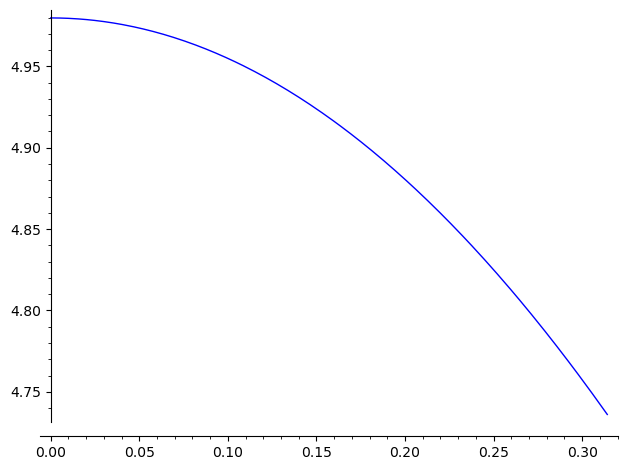

In [10]:
plot(area, theta, 0, pi/10)

In [11]:
min_area = area.substitute(theta=pi/10).simplify_full()
show(min_area)
print(numerical_approx(min_area))
min_area

-1/8*(17*sqrt(5) - 38)*sqrt(2*sqrt(5) + 10)*sqrt(-2*sqrt(5) + 10)/(72*sqrt(5) - 161)

4.73606797751110


-1/8*(17*sqrt(5) - 38)*sqrt(2*sqrt(5) + 10)*sqrt(-2*sqrt(5) + 10)/(72*sqrt(5) - 161)

In [12]:
min_area = min_area.substitute(sqrt(2*sqrt(5)+10) == sqrt(80)/sqrt(-2*sqrt(5)+10))
show(min_area)
print(numerical_approx(min_area))
min_area

-1/2*sqrt(5)*(17*sqrt(5) - 38)/(72*sqrt(5) - 161)

4.73606797751110


-1/2*sqrt(5)*(17*sqrt(5) - 38)/(72*sqrt(5) - 161)

In [13]:
min_area = ((min_area.numerator()*(72*sqrt(5)+161)).simplify_full()
            /(min_area.denominator()*(72*sqrt(5)+161)).simplify_full())
show(min_area)
print(numerical_approx(min_area))
min_area

sqrt(5) + 5/2

4.73606797749979


sqrt(5) + 5/2